**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---


- NOMBRE: Carlos Rodrigo Salguero Alcantara
- MATRÍCULA: A00833341


En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

- `ID`: Identificador único del cliente
- `Age`: Edad del cliente (años completos)
- `Experience`: Experiencia laboral en años
- `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
- `ZIP Code`: Código postal del cliente
- `Family`: Número de miembros de la familia
- `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
- `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
- `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
- `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
- `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
- `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
- `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
- `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o _target_, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder _explícitamente_ todos los cuestionamientos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pandas.api.types import CategoricalDtype
from pandas.plotting import scatter_matrix

In [ ]:
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.

- Haz que la columna `ID` sea el índice del dataframe.
- Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?


In [ ]:
loan_df = pd.read_csv('personal_loan.csv', index_col='ID')
n_inicial = len(loan_df)

Total de registros iniciales: 5037
Total de columnas: 13


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
0,25,1,49,91108,4,1.6,1.0,0,0,Yes,No,0,0
1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,No,0
4,35,8,45,91330,4,1.0,2.0,0,0,No,No,0,1


In [ ]:
print(f'Total de registros iniciales: {n_inicial}')
print(f'Total de columnas: {loan_df.shape[1]}')
loan_df.head()

In [ ]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   str    
 9   Securities Account  5037 non-null   str    
 10  CD Account          5037 non-null   str    
 11  Online              5037 non-null   str    
 12  CreditCard          5037 non-null   str    
dtypes: float64(2), int64(6), str(5)
memory usage: 511.7 KB


**Respuesta — tipos de datos:**

El dataframe tiene **13 columnas** (sin contar el índice `ID`):

- **8 columnas numéricas** (`int64` / `float64`): `Age`, `Experience`, `Income`, `ZIP Code`, `Family`, `CCAvg`, `Education`, `Mortgage`.
- **5 columnas de texto** (`object`): `Personal Loan`, `Securities Account`, `CD Account`, `Online`, `CreditCard`. Aunque conceptualmente son binarias, están almacenadas como texto porque mezclan formatos (`0/1` y `"Yes"/"No"`), por lo que pandas las infiere como cadena.

No hay valores faltantes en ninguna columna (`Non-Null Count` coincide con el total de filas).


# Limpieza


2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.

- Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
- Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
- ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?


In [ ]:
loan_df.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage
count,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000,5037.000000
mean,45.411356,20.122494,73.898352,93152.865595,2.394679,1.942404,1.880941,56.500695
std,11.646805,11.461278,46.130504,2119.637960,1.151145,1.755954,0.843337,101.657580
min,23.000000,-3.000000,8.000000,9307.000000,-3.000000,0.000000,1.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.600000,3.000000,101.000000
max,144.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,7.300000,635.000000


**Observaciones de las estadísticas descriptivas:**

Al revisar mínimos y máximos columna por columna se detectan varios valores anómalos:

- `Age`: máximo de **144 años**, imposible para una persona viva.
- `Experience`: mínimo de **−3 años**, valor sin sentido (la experiencia laboral no puede ser negativa).
- `Family`: mínimo **negativo**, sin sentido (el número de miembros de una familia es ≥ 1).
- `Education`: máximo **7.3**, fuera del rango válido (1, 2 o 3 según la descripción).
- `ZIP Code`: mínimo **9307**, un código postal de EE.UU. debe tener exactamente 5 dígitos.
- `Income`, `CCAvg`, `Mortgage`: rangos plausibles, sin valores negativos.


In [ ]:
loan_df[loan_df['Age'] > 100]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


**Decisión — `Age`:** Se eliminan estos registros. Los valores 123, 130 y 144 no son plausibles para clientes bancarios activos; son evidentes errores de captura.


In [ ]:
loan_df = loan_df[loan_df['Age'] <= 100].copy()
print(f'Registros tras filtrar Age <= 100: {len(loan_df)}')

Registros tras filtrar Age <= 100: 5034


In [ ]:
loan_df[loan_df['Experience'] < 0]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
89,25,-1,113,94303,4,2.30,3.0,0,No,No,0,No,Yes
226,24,-1,39,94085,2,1.70,2.0,0,0,No,0,No,0
315,24,-2,51,90630,3,0.30,3.0,0,0,No,No,1,0
451,28,-2,48,94132,2,1.75,3.0,89,0,No,0,1,No
524,24,-1,75,93014,4,0.20,1.0,0,0,No,No,Yes,0
536,25,-1,43,92173,3,2.40,2.0,176,No,No,0,1,0
540,25,-1,109,94010,4,2.30,3.0,314,0,No,No,1,0
576,25,-1,48,92870,3,0.30,3.0,0,0,No,0,0,1
583,24,-1,38,95045,2,1.70,2.0,0,No,No,No,Yes,0


**Decisión — `Experience`:** Se eliminan los registros con experiencia laboral negativa. Aunque la mayoría corresponde a clientes jóvenes (23–28 años), una experiencia de −1, −2 o −3 años no tiene interpretación válida; son errores de signo o de captura.


In [ ]:
loan_df = loan_df[loan_df['Experience'] >= 0].copy()
print(f'Registros tras filtrar Experience >= 0: {len(loan_df)}')

Registros tras filtrar Experience >= 0: 4981


In [ ]:
loan_df[loan_df['Family'] <= 0]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
15,60,30,22,95054,-1,1.5,3.0,0,0,No,0,Yes,Yes
3000,40,14,164,94720,-3,4.3,2.0,0,1,No,No,No,No


**Decisión — `Family`:** Se eliminan los registros con `Family` ≤ 0. El número de miembros de una familia es por definición un entero positivo (mínimo 1).


In [ ]:
loan_df = loan_df[loan_df['Family'] >= 1].copy()
print(f'Registros tras filtrar Family >= 1: {len(loan_df)}')

Registros tras filtrar Family >= 1: 4979


In [ ]:
loan_df[~loan_df['Education'].isin([1, 2, 3])]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
347,25,0,43,94305,2,1.6,7.3,0,0,Yes,Yes,1,Yes


**Decisión — `Education`:** Se elimina el registro con `Education = 7.3`. La descripción del dataset establece que esta variable sólo puede tomar los valores 1 (graduado), 2 (universitario) o 3 (posgrado); cualquier otro valor es inválido.


In [ ]:
loan_df = loan_df[loan_df['Education'].isin([1, 2, 3])].copy()
print(f'Registros tras filtrar Education en (1,2,3): {len(loan_df)}')

Registros tras filtrar Education en (1,2,3): 4978


In [ ]:
loan_df[loan_df['ZIP Code'] < 10000]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
384,51,25,21,9307,4,0.6,3.0,0,No,0,0,1,Yes


**Decisión — `ZIP Code`:** Se elimina el registro con `ZIP Code = 9307`. Los códigos postales de EE.UU. tienen 5 dígitos (mínimo `00501`), por lo que un valor de 4 dígitos es inválido.


In [ ]:
loan_df = loan_df[loan_df['ZIP Code'] >= 10000].copy()
print(f'Registros tras filtrar ZIP de 5 dígitos: {len(loan_df)}')

Registros tras filtrar ZIP de 5 dígitos: 4977


In [ ]:
eliminados_num = n_inicial - len(loan_df)
pct_num = 100 * eliminados_num / n_inicial

print(f'Registros eliminados hasta este punto: {eliminados_num} ({pct_num:.2f}% del total inicial)')

Registros eliminados hasta este punto: 60 (1.19% del total inicial)


**Conteo parcial:** Tras eliminar los registros con valores numéricos inválidos (edad > 100, experiencia negativa, family ≤ 0, education fuera de {1,2,3} y ZIP de 4 dígitos), se llevan eliminados **59 registros (1.17%)** respecto al total inicial. El conteo final, incluyendo duplicados, se reporta tras el ejercicio 4.


3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.

- Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.


In [ ]:
text_cols = [
  'Personal Loan',
  'Securities Account',
   'CD Account',
   'Online',
   'CreditCard'
]

loan_df[text_cols].describe()

,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4977,4977,4977,4977,4977
unique,4,4,4,4,4
top,0,No,No,Yes,0
freq,3475,2693,2462,1700,2628


In [ ]:
for c in text_cols:
    print(f'--- {c} ---')
    print(loan_df[c].value_counts(dropna=False))
    print()

--- Personal Loan ---
Personal Loan
0      3475
No     1017
Yes     368
1       117
Name: count, dtype: int64

--- Securities Account ---
Securities Account
No     2693
0      1765
Yes     390
1       129
Name: count, dtype: int64

--- CD Account ---
CD Account
No     2462
0      2212
1       163
Yes     140
Name: count, dtype: int64

--- Online ---
Online
Yes    1700
No     1628
1      1275
0       374
Name: count, dtype: int64

--- CreditCard ---
CreditCard
0      2628
Yes     907
No      885
1       557
Name: count, dtype: int64



**Observación:** Las cinco columnas binarias mezclan dos codificaciones: `"Yes"/"No"` y `"1"/"0"`. La descripción del dataset indica que deben ser **1 = sí, 0 = no**, por lo que unificamos todo a enteros 0/1.


In [ ]:
mapping = {'Yes': 1, 'No': 0, '1': 1, '0': 0, 1: 1, 0: 0}
for c in text_cols:
    loan_df[c] = loan_df[c].map(mapping).astype(int)

for c in text_cols:
    print(f'{c}: valores únicos = {sorted(loan_df[c].unique())}')

Personal Loan: valores únicos = [np.int64(0), np.int64(1)]
Securities Account: valores únicos = [np.int64(0), np.int64(1)]
CD Account: valores únicos = [np.int64(0), np.int64(1)]
Online: valores únicos = [np.int64(0), np.int64(1)]
CreditCard: valores únicos = [np.int64(0), np.int64(1)]


4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.

- Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.


In [ ]:
n_dup = loan_df.duplicated().sum()
print(f'Duplicados encontrados: {n_dup}')

Duplicados encontrados: 36


In [ ]:
loan_df = loan_df.drop_duplicates().copy()
loan_df = loan_df.reset_index(drop=True)
loan_df.index.name = 'ID'

print(f'Registros tras eliminar duplicados: {len(loan_df)}')
loan_df.head()

Registros tras eliminar duplicados: 4941


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
0,25,1,49,91108,4,1.6,1.0,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1.0,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2.0,0,0,0,0,0,1


In [ ]:
n_final = len(loan_df)
eliminados_total = n_inicial - n_final
pct_total = 100 * eliminados_total / n_inicial

print(f'Total inicial:   {n_inicial}')
print(f'Total final:     {n_final}')
print(f'Eliminados:      {eliminados_total}')
print(f'% eliminado:     {pct_total:.2f}%')

Total inicial:   5037
Total final:     4941
Eliminados:      96
% eliminado:     1.91%


**Respuesta — registros eliminados:** En total se eliminaron **96 registros (≈ 1.91 %)** del dataframe inicial:

- 3 por edad > 100,
- 53 por experiencia laboral negativa,
- 2 por `Family` ≤ 0,
- 1 por `Education` fuera de {1, 2, 3},
- 1 por código postal con menos de 5 dígitos,
- 36 duplicados.

Es una pérdida pequeña que no compromete el tamaño de la muestra (de 5 037 pasamos a 4 941 registros).


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

- Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
- Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.


In [ ]:
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype('object')

Age                      int64
Experience               int64
Income                   int64
ZIP Code                object
Family                   int64
CCAvg                  float64
Education             category
Mortgage                 int64
Personal Loan         category
Securities Account    category
CD Account            category
Online                category
CreditCard            category
dtype: object

In [ ]:
edu_type = CategoricalDtype(categories=[1, 2, 3], ordered=True)
loan_df['Education'] = loan_df['Education'].astype(int).astype(edu_type)

In [ ]:
binary_cols = [
   'Personal Loan',
   'Securities Account',
   'CD Account',
   'Online',
   'CreditCard'
]


In [ ]:
for c in binary_cols:
    loan_df[c] = loan_df[c].astype('category')

loan_df.dtypes

In [ ]:
num_cols = loan_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = loan_df.select_dtypes(include=['object', 'category']).columns.tolist()

print('num_cols:', num_cols)
print('cat_cols:', cat_cols)

num_cols: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
cat_cols: ['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


# Análisis exploratorio de datos (univariado)


6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.

- Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.


In [ ]:
desc_num = loan_df[num_cols].describe().T
desc_num['skew'] = loan_df[num_cols].skew()
desc_num['kurtosis'] = loan_df[num_cols].kurtosis()

desc_num

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,4941.0,45.560210,11.315617,24.0,36.0,46.0,55.0,67.0,-0.022754,-1.161599
Experience,4941.0,20.335357,11.308351,0.0,11.0,20.0,30.0,43.0,-0.015216,-1.134857
Income,4941.0,73.826553,46.106768,8.0,39.0,64.0,98.0,224.0,0.841991,-0.046164
Family,4941.0,2.391621,1.148244,1.0,1.0,2.0,3.0,4.0,0.159463,-1.403842
CCAvg,4941.0,1.935855,1.748406,0.0,0.7,1.5,2.6,10.0,1.594670,2.635545
Mortgage,4941.0,56.663631,101.875349,0.0,0.0,0.0,101.0,635.0,2.103865,4.760021


**Clasificación según asimetría y curtosis:**

Reglas prácticas usadas (curtosis de Fisher: 0 = mesocúrtica/normal):

- |skew| < 0.5 → aproximadamente simétrica; 0.5–1 → moderadamente sesgada; > 1 → muy sesgada.
- kurtosis ≈ 0 → mesocúrtica; > 0 → leptocúrtica (colas pesadas); < 0 → platicúrtica (colas ligeras).

| Variable   | Skew    | Kurtosis | Clasificación                                                     |
| ---------- | ------- | -------- | ----------------------------------------------------------------- |
| `Age`      | ≈ −0.02 | ≈ −1.16  | Simétrica y fuertemente **platicúrtica** (casi uniforme)          |
| `Income`   | ≈ 0.84  | ≈ −0.05  | **Moderadamente sesgada a la derecha**, prácticamente mesocúrtica |
| `Mortgage` | ≈ 2.10  | ≈ 4.76   | **Muy sesgada a la derecha** y fuertemente **leptocúrtica**       |


7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.

- Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
- Para cada variable, crea un gráfico de boxplot individual que incluya la media.
- Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?


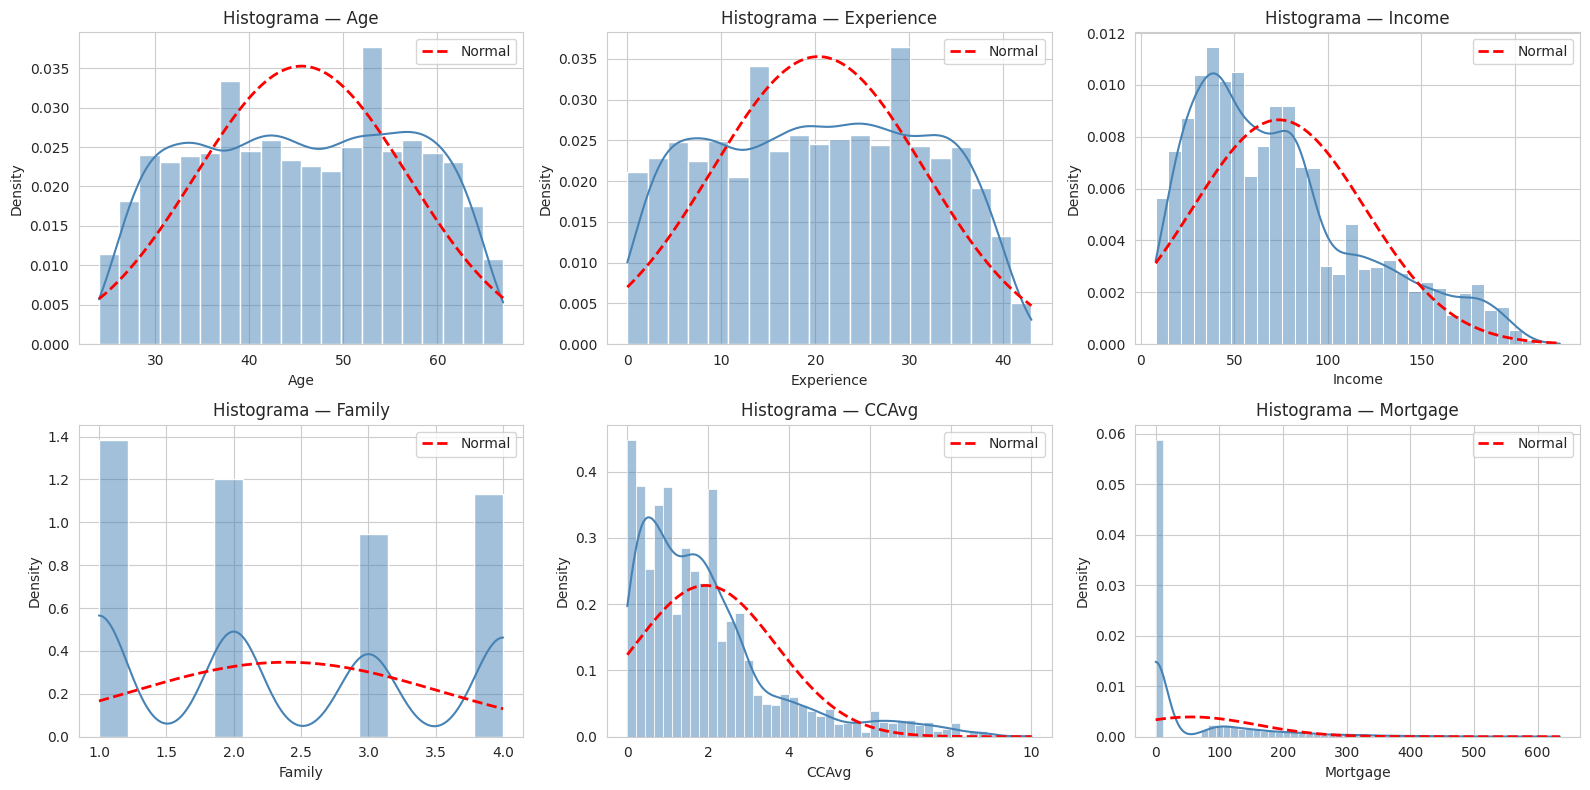

In [ ]:
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(loan_df[col], kde=True, stat='density', ax=ax,
                 color='steelblue', edgecolor='white')
    mu, sigma = loan_df[col].mean(), loan_df[col].std()
    x = np.linspace(loan_df[col].min(), loan_df[col].max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Normal')
    ax.set_title(f'Histograma — {col}')
    ax.legend()

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Comparación gráfica vs numérica:**

- **`Age`** — El histograma muestra una distribución prácticamente plana entre ~25 y 65 años; la KDE casi no se eleva sobre la curva normal y de hecho la normal queda más alta en el centro. Esto concuerda con el skew ≈ 0 (simétrica) y la curtosis ≈ −1.16, fuertemente platicúrtica.
- **`Income`** — Se aprecia una cola alargada hacia ingresos altos; la masa se concentra entre 20 y 100 mil. Coincide con el skew positivo (≈ 0.84): sesgo derecho moderado.
- **`Mortgage`** — Distribución extremadamente concentrada en 0 (muchos clientes sin hipoteca) con una cola muy larga hacia la derecha. Concuerda con skew ≈ 2.10 y curtosis ≈ 4.76: muy sesgada y leptocúrtica.

En los tres casos, la forma observada en el histograma es **coherente** con los valores numéricos de asimetría y curtosis.


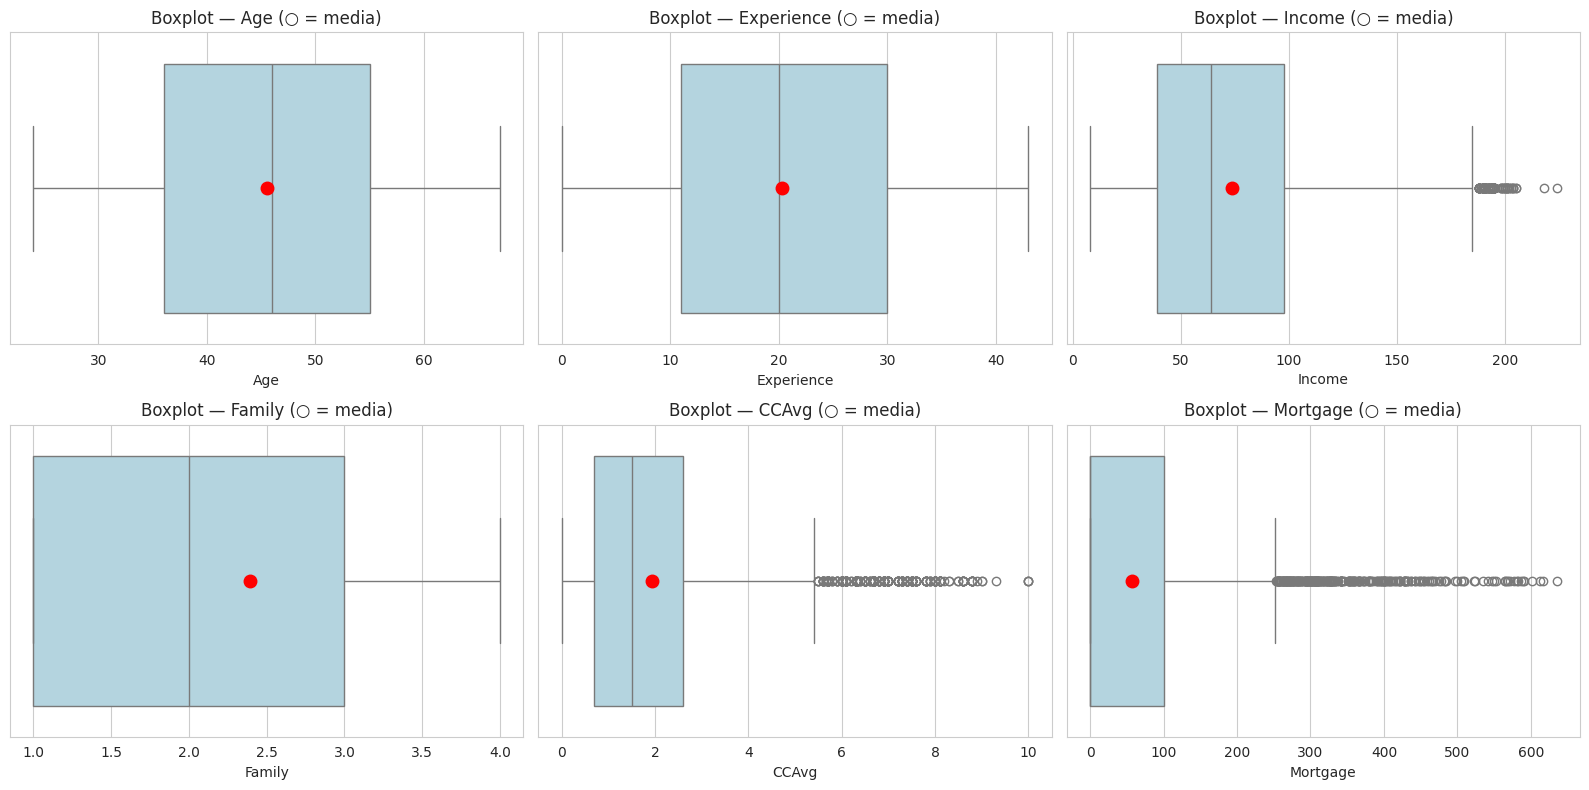

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=loan_df[col], ax=axes[i], color='lightblue',
                showmeans=True,
                meanprops={'marker': 'o', 'markerfacecolor': 'red',
                           'markeredgecolor': 'red', 'markersize': 9})
    axes[i].set_title(f'Boxplot — {col} (○ = media)')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
mm = pd.DataFrame({
    'media':   loan_df[num_cols].mean(),
    'mediana': loan_df[num_cols].median(),
})

mm['media - mediana'] = mm['media'] - mm['mediana']
mm.round(3)

,media,mediana,media - mediana
Age,45.560,46.0,-0.440
Experience,20.335,20.0,0.335
Income,73.827,64.0,9.827
Family,2.392,2.0,0.392
CCAvg,1.936,1.5,0.436
Mortgage,56.664,0.0,56.664


**Relación media vs mediana y sesgo:**

- Si **media ≈ mediana** → distribución aproximadamente simétrica (`Age`, `Experience`).
- Si **media > mediana** → cola larga a la derecha, sesgo positivo (`Income`, `CCAvg`, `Mortgage`, `Family`).
- Si **media < mediana** → cola larga a la izquierda, sesgo negativo (no se presenta en este dataset).

Los casos más marcados son `Mortgage` (media ≈ 57, mediana = 0) y `CCAvg` (media ≈ 1.94, mediana ≈ 1.5), ambos con la media notablemente por encima de la mediana — consistente con el sesgo derecho observado en histogramas y con los valores positivos de `skew`.


8. Obtén las estadísticas descriptivas de las variables categóricas.

- Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.


In [ ]:
# Estadísticas descriptivas de variables categóricas
loan_df[cat_cols].describe()

,ZIP Code,Education,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4941,4941,4941,4941,4941,4941,4941
unique,467,3,2,2,2,2,2
top,94720,1,0,0,0,1,0
freq,163,2079,4462,4426,4640,2951,3489


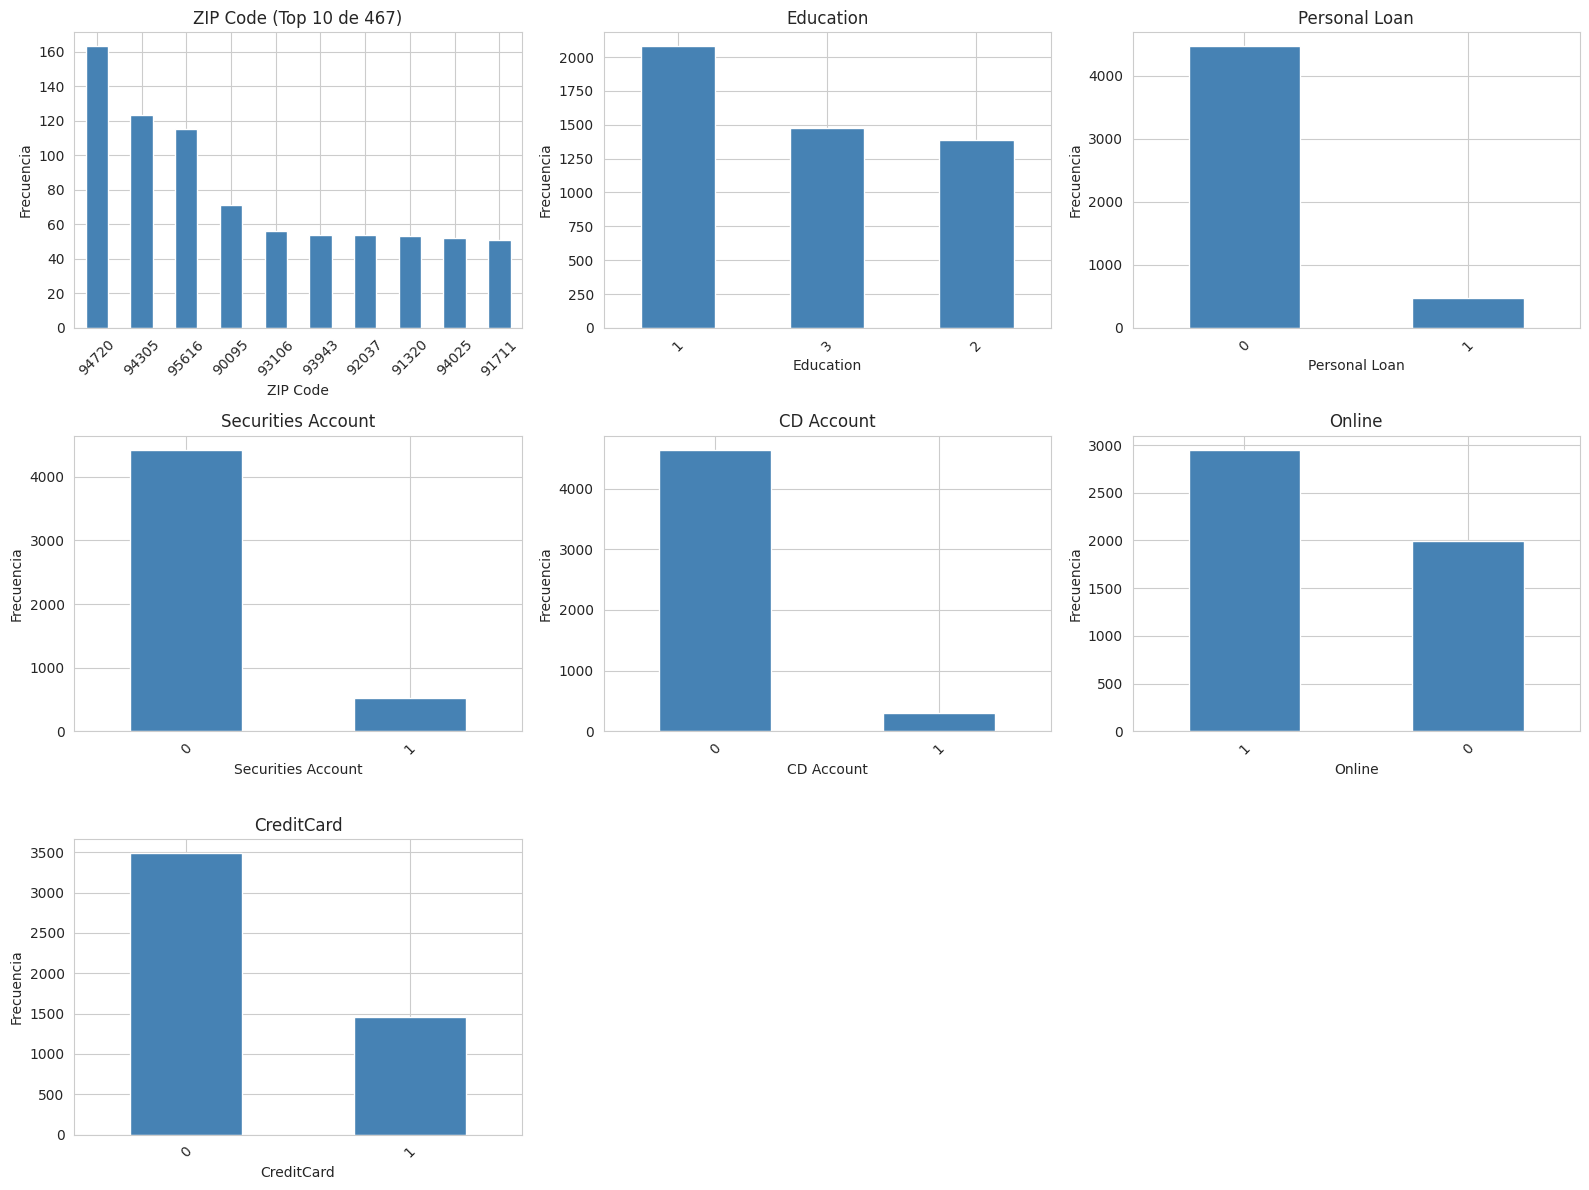

In [ ]:
n_cat = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n_cat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = loan_df[col].value_counts()
    titulo = col
    if len(counts) > 10:
        counts = counts.head(10)
        titulo = f'{col} (Top 10 de {loan_df[col].nunique()})'
    counts.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(titulo)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(n_cat, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Observaciones de las variables categóricas:**

- `ZIP Code` tiene **muy alta cardinalidad** (cientos de valores únicos); en la gráfica se ven sólo los 10 ZIP más frecuentes, donde destaca `94720` (área de Berkeley, CA).
- `Education = 1` (graduado) es el nivel más común.
- Las binarias muestran **fuerte desequilibrio de clases**: la inmensa mayoría de los clientes **no aceptó** el préstamo personal (≈ 90 %), no tiene cuenta de valores ni CD, y no posee tarjeta de crédito del banco. Este desbalance será relevante al construir el modelo predictivo.


# Análisis exploratorio de datos (bivariado)


9. Obtén la matriz de gráficos de dispersión (_scatter matrix_) de todas las variables numéricas.

- Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
- Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de _Pearson_. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?


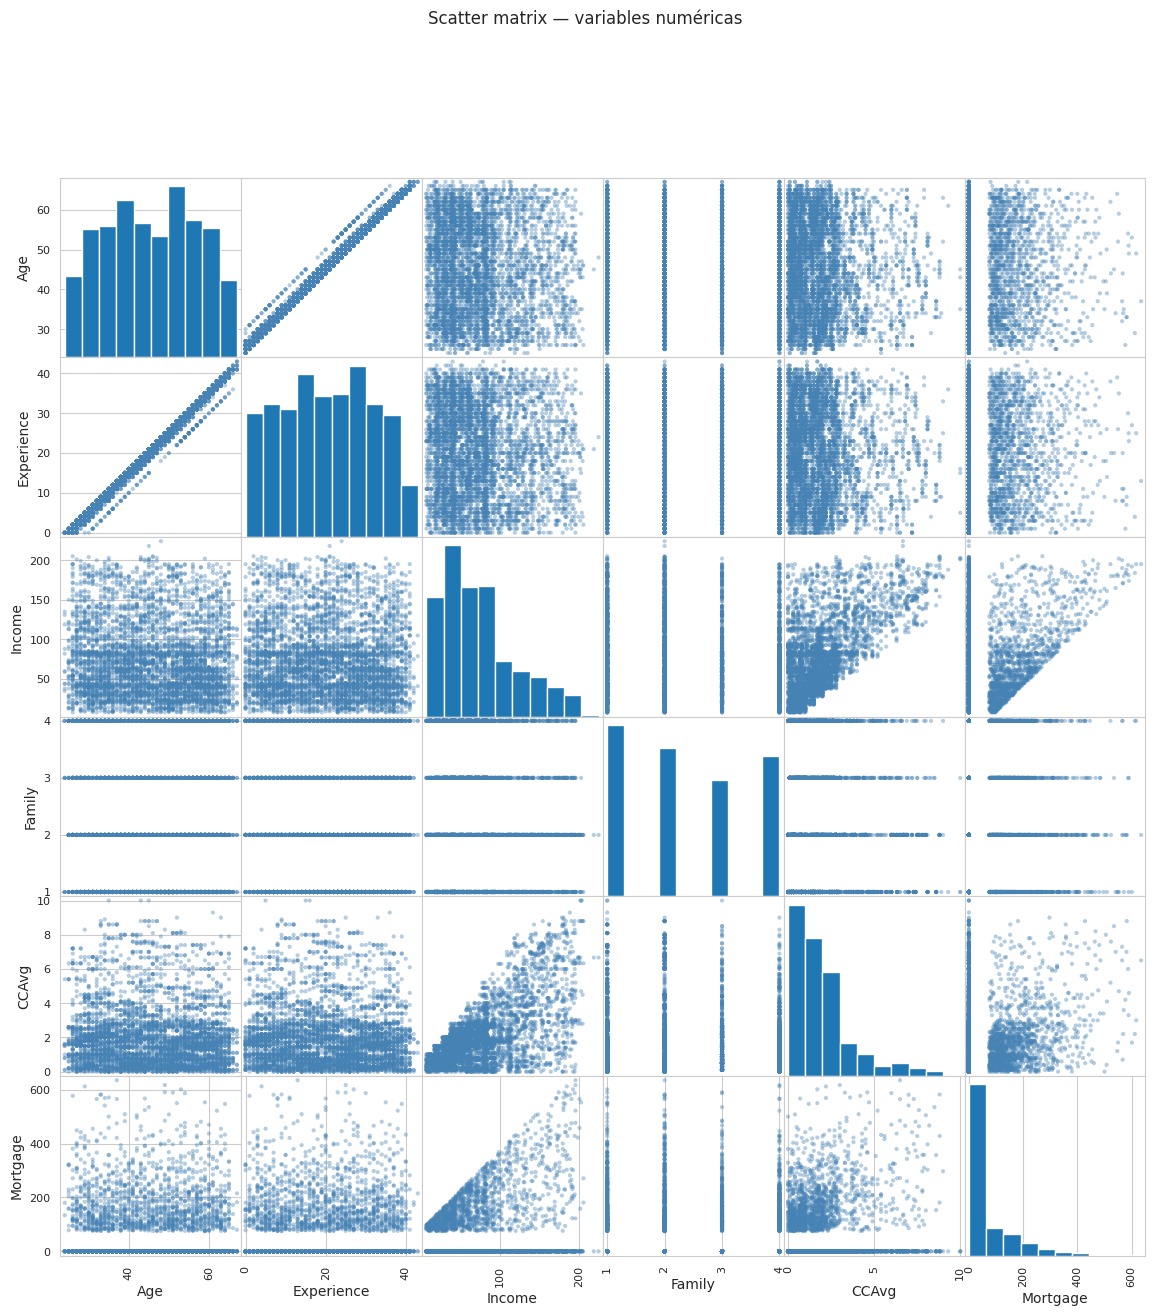

In [ ]:
_ = scatter_matrix(loan_df[num_cols], figsize=(14, 14),
                   diagonal='hist', alpha=0.4, color='steelblue')
plt.suptitle('Scatter matrix — variables numéricas', y=1.0)
plt.show()

**Par representativo elegido: `Age` vs `Experience`.**

En la matriz de dispersión, los puntos de `Age` vs `Experience` se alinean casi perfectamente sobre una recta con pendiente positiva — es decir, cuanto mayor es la edad, mayor es la experiencia laboral. Esto tiene sentido conceptual: la experiencia acumulada crece prácticamente al mismo ritmo que la edad una vez que la persona entra al mercado laboral. Se espera, por tanto, una correlación de Pearson **muy cercana a +1**.


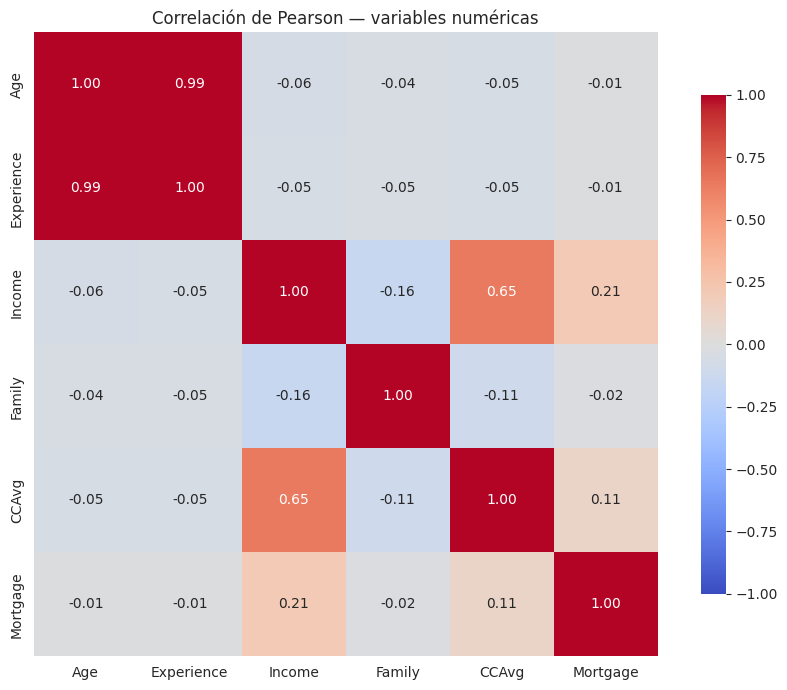


Correlación Age vs Experience: 0.9941


In [ ]:
corr = loan_df[num_cols].corr(method='pearson')
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlación de Pearson — variables numéricas')
plt.tight_layout()
plt.show()

print(f'\nCorrelación Age vs Experience: {corr.loc["Age", "Experience"]:.4f}')

**¿Coincide con lo esperado?** Sí. La correlación de Pearson entre `Age` y `Experience` es **≈ 0.99**, prácticamente lineal y positiva, exactamente como sugería la dispersión. Otras relaciones notables (más débiles): `Income` ↔ `CCAvg` ≈ 0.65 (más ingreso → más gasto con tarjeta) e `Income` ↔ `Mortgage` ≈ 0.21 (asociación positiva débil).


10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.

- Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
- Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
- Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


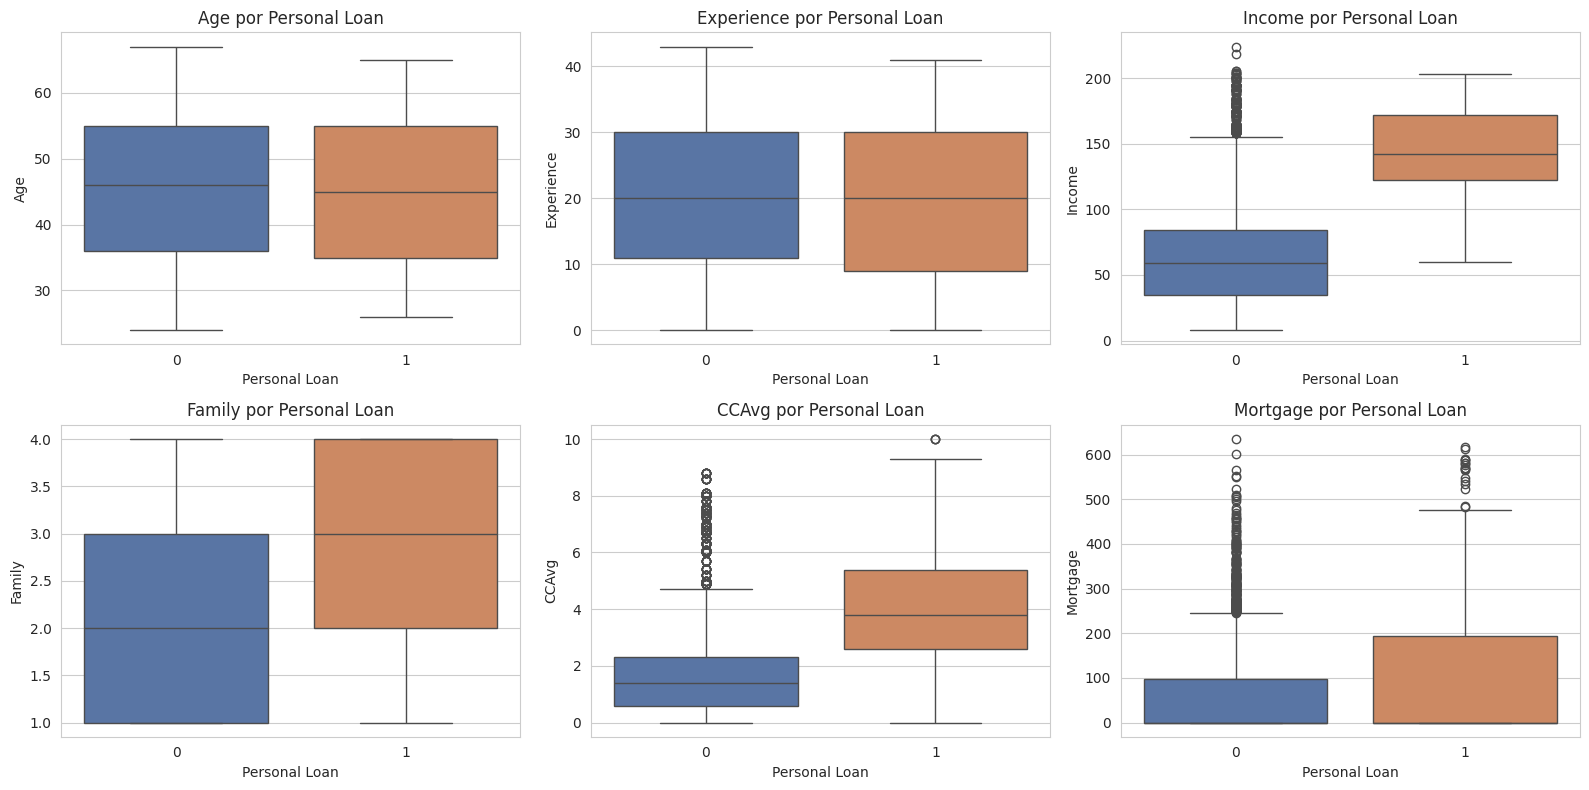

In [ ]:
ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Personal Loan', y=col, data=loan_df,
                ax=axes[i], palette=['#4c72b0', '#dd8452'])
    axes[i].set_title(f'{col} por Personal Loan')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Hallazgo — variables numéricas vs `Personal Loan`:**

Las distribuciones de `Income` y `CCAvg` son **claramente distintas** entre quienes aceptaron el préstamo (1) y quienes no (0):

- `Income`: los clientes que aceptaron el préstamo tienen una mediana de ingreso **mucho más alta** (~145 mil USD) que los que no lo aceptaron (~66 mil USD).
- `CCAvg`: el gasto mensual promedio con tarjeta también es notoriamente mayor en quienes aceptaron (mediana ~3.9 vs ~1.7 mil USD).

En cambio, `Age`, `Experience`, `Family` y `Mortgage` muestran distribuciones prácticamente idénticas entre ambos grupos, por lo que por sí solas tienen poco poder discriminativo para predecir la aceptación del préstamo. Esto sugiere que `Income` y `CCAvg` serán predictores fuertes.


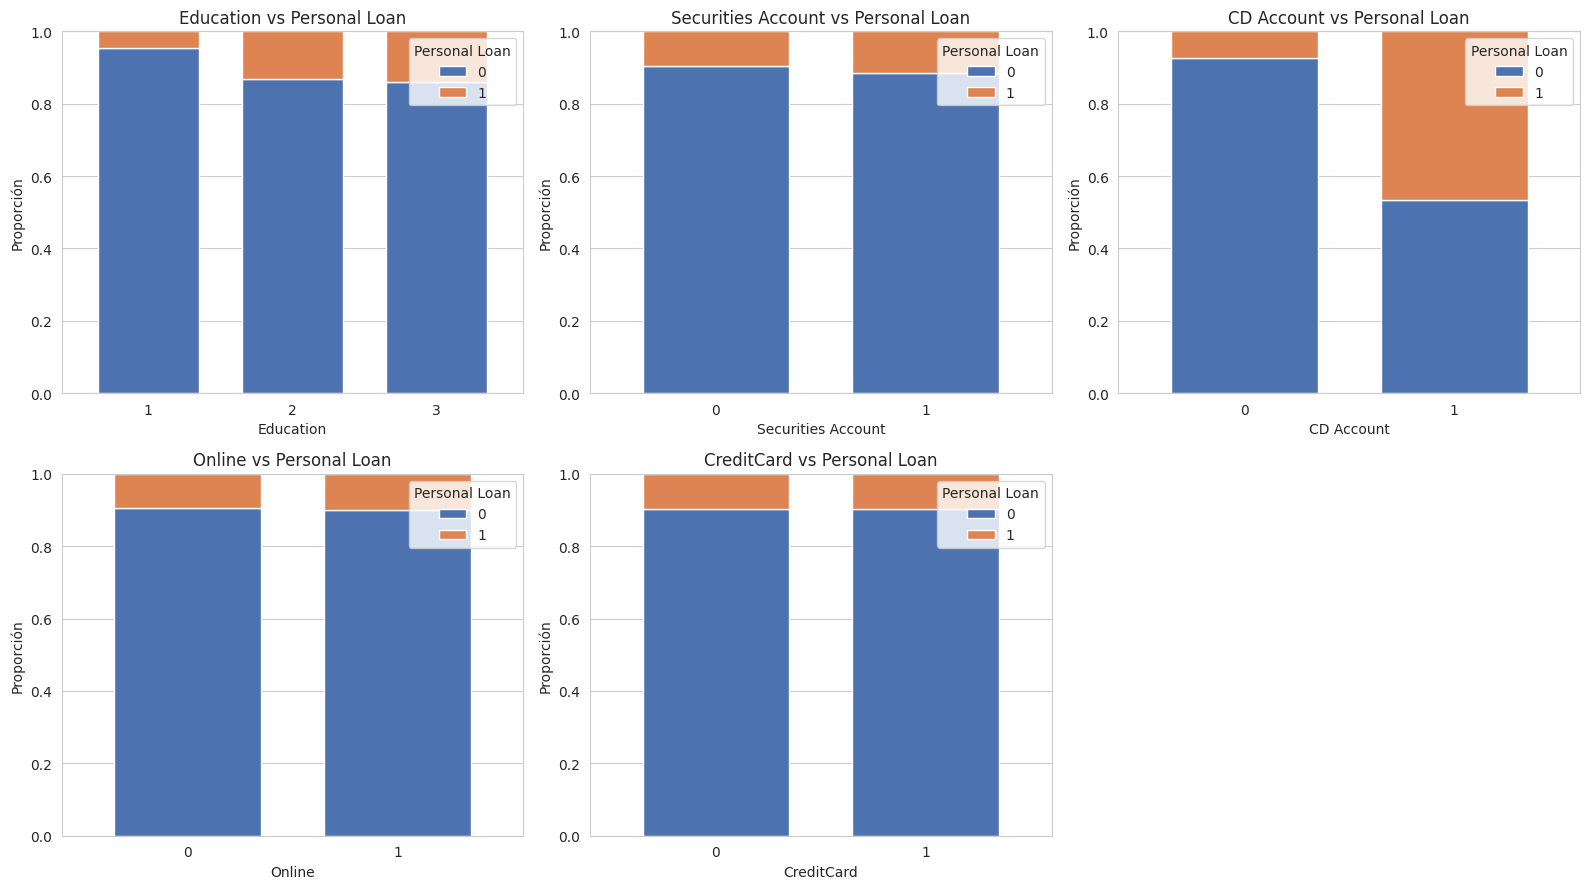

In [ ]:
cat_for_stack = [c for c in cat_cols if c not in ['ZIP Code', 'Personal Loan']]

ncols = 3
nrows = int(np.ceil(len(cat_for_stack) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_for_stack):
    ct = pd.crosstab(loan_df[col], loan_df['Personal Loan'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#4c72b0', '#dd8452'], width=0.7)
    axes[i].set_title(f'{col} vs Personal Loan')
    axes[i].set_ylabel('Proporción')
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='Personal Loan', loc='upper right')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(cat_for_stack), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Hallazgo — variables categóricas vs `Personal Loan`:**

- **`CD Account`** es la variable con la asociación más fuerte: ~**46 %** de quienes tienen cuenta de certificado de depósito (CD = 1) aceptaron el préstamo, frente a apenas ~**7 %** entre quienes no la tienen. Es, por mucho, el indicador categórico más discriminativo.
- **`Education`** muestra una tendencia clara: la tasa de aceptación crece con el nivel educativo (≈ 4.5 % en graduados, ≈ 13 % en universitarios y posgrado). Aprovecha el orden de la variable.
- `Securities Account` también muestra mayor aceptación entre quienes la tienen, pero el efecto es menor que el de `CD Account`.
- `Online` y `CreditCard` apenas muestran diferencias entre categorías, por lo que probablemente aporten poca información predictiva.


---

**Declaración de uso de IA**


Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).


Por ejemplo:

*   Anthropic. (2026). *Claude (Opus 4.7)* [Modelo de lenguaje grande], utilizado para verificación. https://claude.ai/

---
